## Import and Load data

In [1]:
from qualibrate import QualibrationNode
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import json
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path


2026-03-21 09:12:12,043 - qm - INFO     - Starting session: b6609835-37ed-43a3-86f0-677cf4f1c4f2


In [2]:
id_qpt, id_gst, id_ell = 946, 781, 947
gst_depth = 4
node = QualibrationNode('robustness_to_fidelity')
data_path = Path("data/gst_qpt_ellipsoid").resolve()
da_gst = node.load_from_id(id_gst, base_path=data_path).results['ds'].sel(depth=gst_depth).sel(model_type='CPTP').robustness
da_qpt = node.load_from_id(id_qpt, base_path=data_path).results['ds'].sel(model_type='mitigated').robustness
da_ell = node.load_from_id(id_ell, base_path=data_path).results['ds'].sel(model_type='MLE data').robustness
da_fid = node.load_from_id(id_qpt, base_path=data_path).results['ds'].sel(model_type='mitigated').fidelity

da_gst = da_gst.assign_coords(fidelity=da_fid)
da_qpt = da_qpt.assign_coords(fidelity=da_fid)
da_ell = da_ell.assign_coords(fidelity=da_fid)

2026-03-21 09:12:15,293 - qualibrate - INFO - Creating node robustness_to_fidelity


## ellipsoid data analyze again

In [6]:
import itertools

def get_equivalent_ellipsoid_rotations(R, axes, center):
    R = np.array(R)
    permutations = list(itertools.permutations([0, 1, 2]))
    signs = list(itertools.product([1, -1], repeat=3))
    valid_configurations = []
    for perm in permutations:
        for sign in signs:
            R_new = np.zeros((3, 3))
            
            R_new[:, 0] = sign[0] * R[:, perm[0]]
            R_new[:, 1] = sign[1] * R[:, perm[1]]
            R_new[:, 2] = sign[2] * R[:, perm[2]]
            
            if np.linalg.det(R_new) > 0.5:
                new_axes = [axes[perm[0]], axes[perm[1]], axes[perm[2]]]
                
                new_center = [center[perm[0]], center[perm[1]], center[perm[2]]]
                
                valid_configurations.append({
                    "rotation_matrix": R_new,
                    "original_axis_order": perm,
                    "signs": sign,
                    "axes_lengths": new_axes,
                    "center": new_center 
                })
    return valid_configurations

from quam_libs.quantum_memory.legacy.NoiseAnalyze import Checker, QuantumMemory

def qm_value(axes,center,R):
    qm_analyze = QuantumMemory(axes,center,R)
    choi_state = qm_analyze.choi_state()
    checker = Checker(choi_state)
    choi, count = checker.choi_checker(index=[1], repeat=100, print_reason=False)
    return QuantumMemory.memory_robustness(choi)

/Users/jackchao/Desktop/Project/publication/quantum_memory/data_availability/quantum_memory_data/.venv/lib/python3.12/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


In [7]:
ellipsoid_index = np.arange(922,946,1)
robustness_list = []
R_list = []
axes_list =[]
center_list = []
for index in ellipsoid_index:
    ellipsoid= node.load_from_id(index,base_path=data_path)
    results = ellipsoid.results
    machine = ellipsoid.machine
    center = results['results']['MLE data']['center']
    axes = results['results']['MLE data']['axes']
    for i in range(len(axes)):
        if axes[i] > 1:
            axes[i] = 1 
    R = results['results']['MLE data']['R']
    param = results['results']['MLE data']['param']
    qmr = qm_value(axes, center, R)
    dd = get_equivalent_ellipsoid_rotations(R,axes,center)
    for j in range(len(dd)):
        R_test = dd[j]['rotation_matrix']
        axes_test = dd[j]['axes_lengths']
        center_test = dd[i]['center']
        qmr_value = qm_value(axes_test, center_test, R_test)
        if qmr_value > qmr:
            R_max = R_test.copy()
            axes_max = axes_test.copy()
            center_max = center_test.copy()
            qmr = qmr_value
    robustness_list.append(qmr)
    R_list.append(R_max)
    axes_list.append(axes_max)
    center_list.append(center_max)

    

After 2 iterations, the Choi state is valid.
After 2 iterations, the Choi state is valid.
After 3 iterations, the Choi state is valid.
Choi state is invalid:
❌ Choi state is not positive semi-definite. Eigenvalues: [-7.43071457e-07  3.49918505e-03  4.06504626e-02  9.55851096e-01]
After 6 iterations, the Choi state is valid.
After 7 iterations, the Choi state is valid.
After 2 iterations, the Choi state is valid.
After 5 iterations, the Choi state is valid.
After 6 iterations, the Choi state is valid.
After 3 iterations, the Choi state is valid.
After 7 iterations, the Choi state is valid.
After 2 iterations, the Choi state is valid.
After 2 iterations, the Choi state is valid.
After 6 iterations, the Choi state is valid.
After 3 iterations, the Choi state is valid.
Choi state is invalid:
❌ Choi state is not positive semi-definite. Eigenvalues: [-3.46511674e-08  3.33812286e-03  1.30192476e-01  8.66469436e-01]
After 8 iterations, the Choi state is valid.
After 3 iterations, the Choi stat

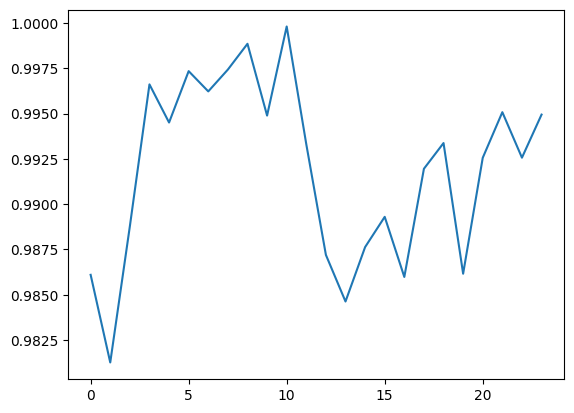

In [8]:
plt.plot(robustness_list)

## qpt vs ellipsoid

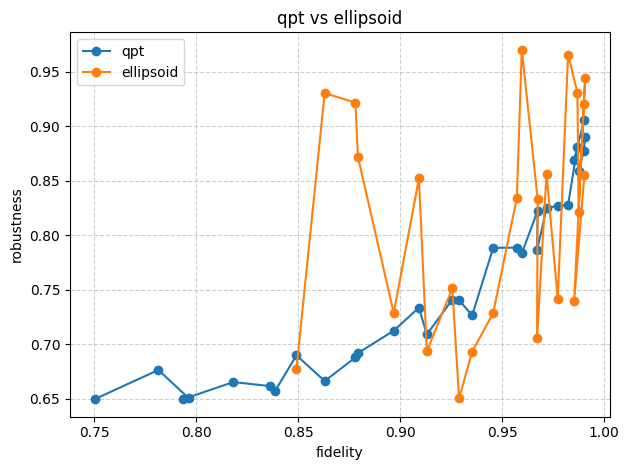

In [3]:
da_qpt.plot.line(
    x='fidelity',
    marker='o',
    linewidth=1.5,
    label='qpt'
)
da_ell.plot.line(
    x='fidelity',
    marker='o',
    linewidth=1.5,
    label='ellipsoid'
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.title('qpt vs ellipsoid')
plt.show()


## gst vs ellipsoid

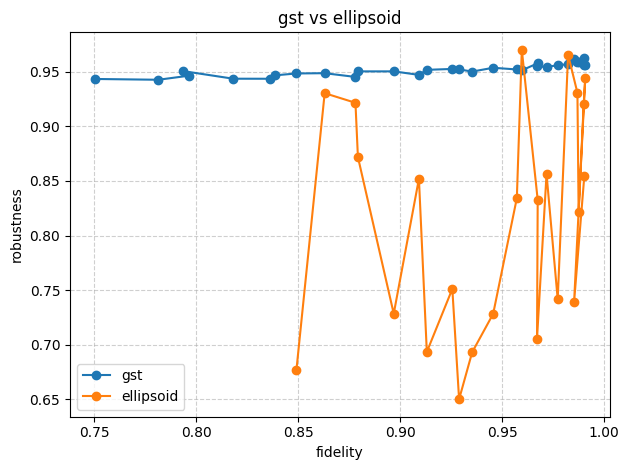

In [4]:
da_gst.plot.line(
    x='fidelity',
    marker='o',
    linewidth=1.5,
    label='gst'
)
da_ell.plot.line(
    x='fidelity',
    marker='o',
    linewidth=1.5,
    label='ellipsoid'
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.title('gst vs ellipsoid')
plt.show()

## gst, qpt ellipsoid

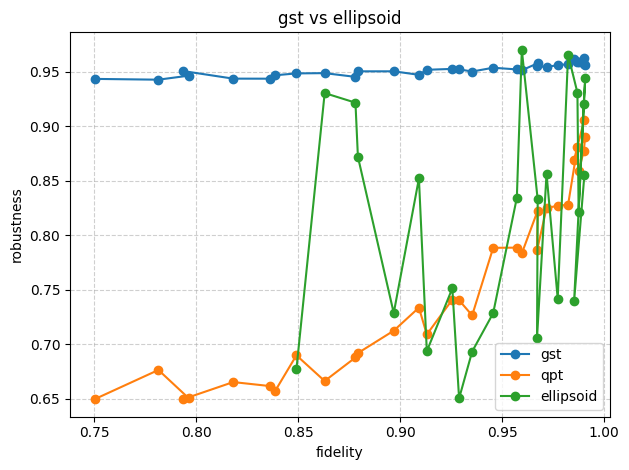

In [5]:
da_gst.plot.line(
    x='fidelity',
    marker='o',
    linewidth=1.5,
    label='gst'
)
da_qpt.plot.line(
    x='fidelity',
    marker='o',
    linewidth=1.5,
    label='qpt'
)
da_ell.plot.line(
    x='fidelity',
    marker='o',
    linewidth=1.5,
    label='ellipsoid'
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.title('gst vs ellipsoid')
plt.show()